# ResNet18 for FER-2013 Emotion Recognition
## Proven Pipeline - 68.26% Accuracy

This notebook implements the exact ResNet18 pipeline that achieved **68.26% accuracy** on the FER-2013 dataset.

**Key Features:**
- ResNet18 architecture with pretrained ImageNet weights
- Advanced data augmentation
- Comprehensive visualizations
- Class distribution analysis
- Sample image displays

## 1. Imports & Device Setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import random
from tqdm.auto import tqdm

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory Available: 17.06 GB


## 2. Configuration

In [2]:
# Paths
TRAIN_DIR ="/kaggle/input/datasets/msambare/fer2013/train"
TEST_DIR = "/kaggle/input/datasets/msambare/fer2013/test"

# Hyperparameters (proven configuration)
BATCH_SIZE = 64
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_CLASSES = 7

# Model save path
MODEL_SAVE_PATH = '/kaggle/working/resnet18_fer2013_best2.pth'

# Emotion classes
EMOTION_CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print("Configuration:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Number of Classes: {NUM_CLASSES}")

Configuration:
  Batch Size: 64
  Epochs: 30
  Learning Rate: 0.001
  Image Size: 224x224
  Number of Classes: 7


## 3. Data Augmentation & Transforms

Using proven augmentation strategy for facial expression recognition.

In [3]:
# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Data transforms configured")

✓ Data transforms configured


## 4. Custom Dataset Class

In [4]:
class FER2013Dataset(Dataset):
    """
    Custom PyTorch Dataset for FER-2013.
    """
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.class_to_idx = {}
        
        # Get class names from directory structure
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}
        
        # Load all samples
        for emotion in classes:
            emotion_dir = os.path.join(root_dir, emotion)
            label = self.class_to_idx[emotion]
            
            for fname in os.listdir(emotion_dir):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    self.samples.append((os.path.join(emotion_dir, fname), label))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image and convert to RGB
        img = Image.open(img_path).convert("RGB")
        
        # Apply transforms
        if self.transform:
            img = self.transform(img)
        
        return img, label

print("✓ Custom Dataset class defined")

✓ Custom Dataset class defined


## 5. Load Datasets

In [5]:
# Create datasets
train_dataset = FER2013Dataset(TRAIN_DIR, transform=train_transform)
test_dataset = FER2013Dataset(TEST_DIR, transform=test_transform)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {list(train_dataset.class_to_idx.keys())}")
print("="*50)


DATASET SUMMARY
Training samples: 28709
Test samples: 7178
Number of classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 6. Visualization: Class Distribution

Analyze the distribution of emotions in the training dataset.

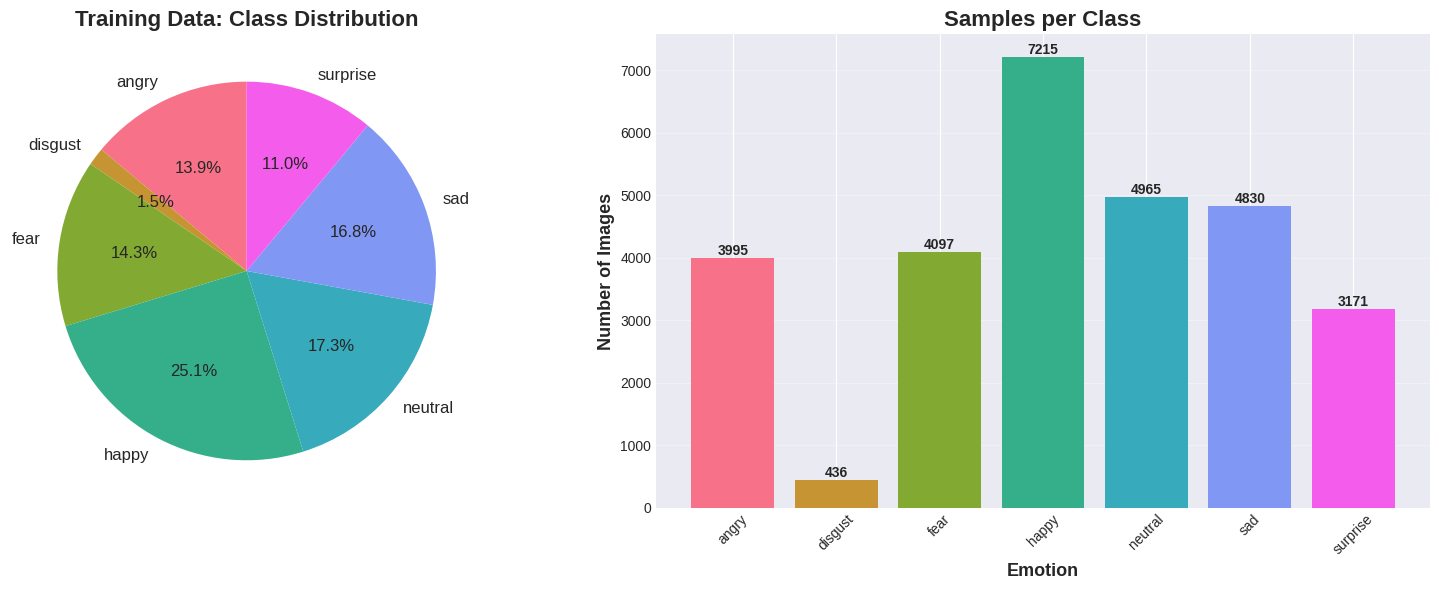


Class Distribution Statistics:
happy       :  7215 images (25.13%)
neutral     :  4965 images (17.29%)
sad         :  4830 images (16.82%)
fear        :  4097 images (14.27%)
angry       :  3995 images (13.92%)
surprise    :  3171 images (11.05%)
disgust     :   436 images ( 1.52%)


In [6]:
# Count samples per class
train_labels = [label for _, label in train_dataset.samples]
label_counts = Counter(train_labels)

# Convert to emotion names
emotion_counts = {train_dataset.idx_to_class[idx]: count for idx, count in label_counts.items()}

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = sns.color_palette('husl', NUM_CLASSES)
axes[0].pie(emotion_counts.values(), labels=emotion_counts.keys(), autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12})
axes[0].set_title('Training Data: Class Distribution', fontsize=16, fontweight='bold')

# Bar chart
emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())
bars = axes[1].bar(emotions, counts, color=colors)
axes[1].set_xlabel('Emotion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Images', fontsize=13, fontweight='bold')
axes[1].set_title('Samples per Class', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\nClass Distribution Statistics:")
print("=" * 50)
total = sum(emotion_counts.values())
for emotion, count in sorted(emotion_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total) * 100
    print(f"{emotion:12s}: {count:5d} images ({percentage:5.2f}%)")
print("=" * 50)

## 7. Visualization: Training Samples

Display 2 sample images from each emotion class in the training set.

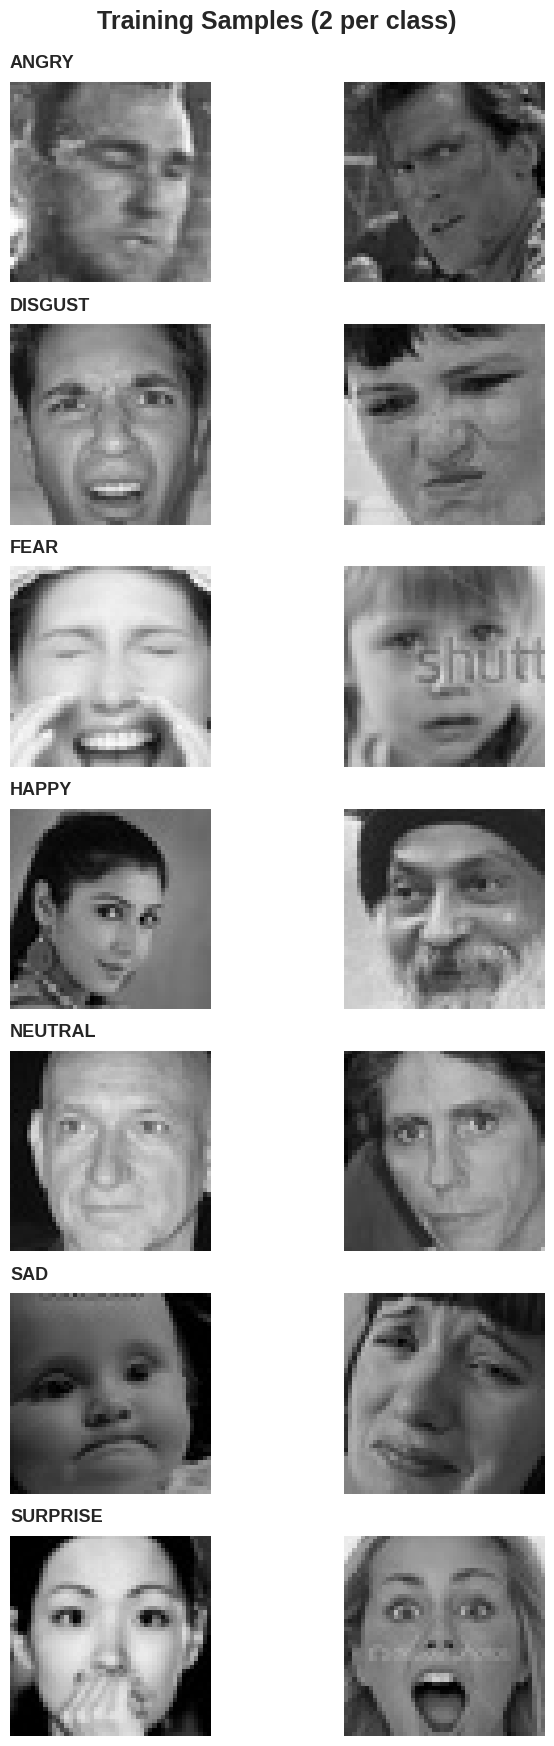

In [7]:
def visualize_samples(data_dir, class_names, samples_per_class=2, title="Sample Images"):
    """
    Visualize sample images from each class.
    """
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(8, 2.5*n_classes))
    fig.suptitle(title, fontsize=18, fontweight='bold', y=0.995)
    
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        if os.path.exists(class_path):
            images = os.listdir(class_path)
            random.shuffle(images)
            
            for j in range(min(samples_per_class, len(images))):
                img_path = os.path.join(class_path, images[j])
                img = Image.open(img_path).convert('RGB')
                
                ax = axes[i, j] if n_classes > 1 else axes[j]
                ax.imshow(img, cmap='gray')
                ax.axis('off')
                
                if j == 0:
                    ax.set_title(f"{class_name.upper()}", 
                               fontsize=13, fontweight='bold', 
                               loc='left', pad=10)
    
    plt.tight_layout()
    plt.show()

# Visualize training samples
visualize_samples(TRAIN_DIR, EMOTION_CLASSES, samples_per_class=2, 
                 title="Training Samples (2 per class)")

## 8. Visualization: Test Samples

Display 2 sample images from each emotion class in the test set.

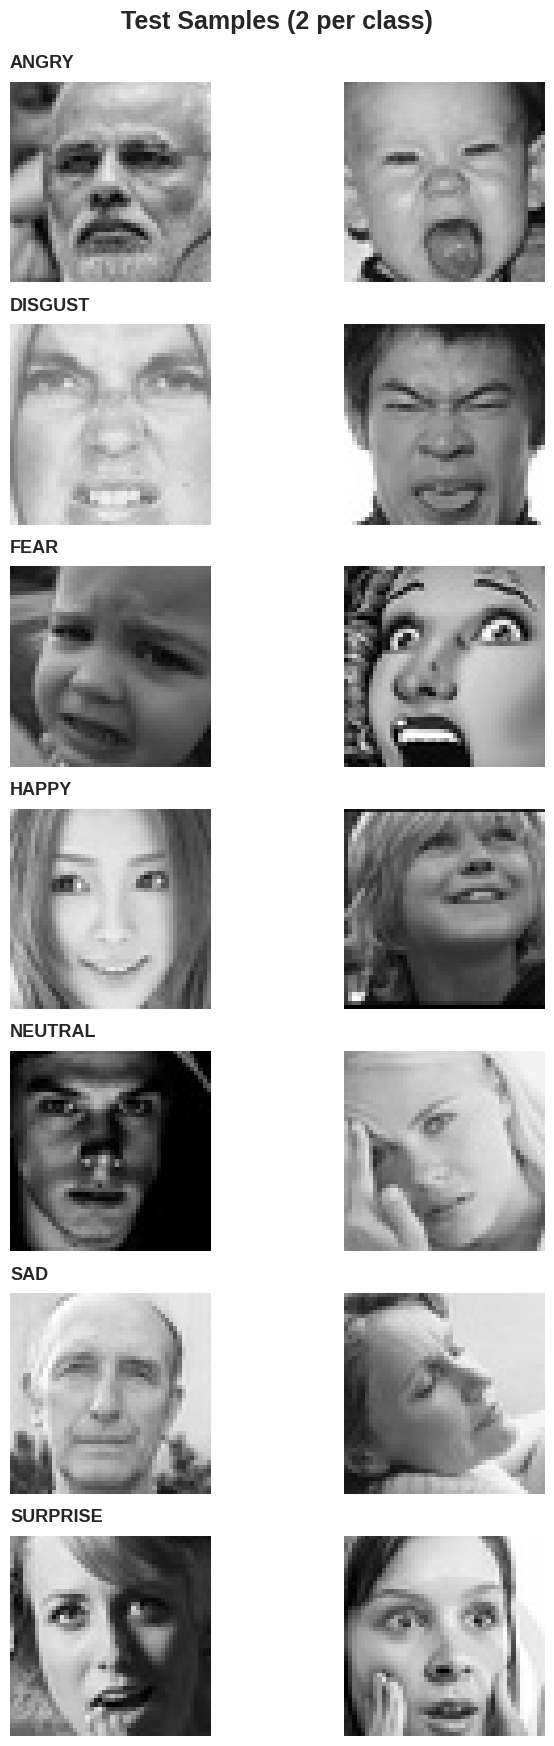

In [8]:
# Visualize test samples
visualize_samples(TEST_DIR, EMOTION_CLASSES, samples_per_class=2, 
                 title="Test Samples (2 per class)")

## 9. Build ResNet18 Model

Using the proven ResNet18 architecture with ImageNet pretrained weights.

In [9]:
def build_resnet18(num_classes=7, pretrained=True):
    """
    Build ResNet18 model with custom classification head.
    """
    # Load pretrained ResNet18
    model = models.resnet18(pretrained=pretrained)
    
    # Modify final fully connected layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

# Build model
model = build_resnet18(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

# Print model summary
print("\n" + "="*50)
print("MODEL ARCHITECTURE: ResNet18")
print("="*50)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*50)
print("\n✓ Model loaded successfully with ImageNet pretrained weights")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



MODEL ARCHITECTURE: ResNet18
Total parameters: 11,180,103
Trainable parameters: 11,180,103

✓ Model loaded successfully with ImageNet pretrained weights


## 10. Loss Function & Optimizer

In [11]:
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)
print("✓ Loss function: CrossEntropyLoss")
print(f"✓ Optimizer: Adam (lr={LEARNING_RATE})")
print("✓ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

✓ Loss function: CrossEntropyLoss
✓ Optimizer: Adam (lr=0.001)
✓ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


## 11. Training Functions

In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100. * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """
    Validate the model.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100. * correct / total:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

print("✓ Training functions defined")

✓ Training functions defined


## 12. Train the Model

Training ResNet18 on FER-2013 dataset.

In [13]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, test_loader, criterion, device)
    
    # Update learning rate
    scheduler.step(val_acc)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, MODEL_SAVE_PATH)
        print(f"  ✓ New best model saved! (Val Acc: {val_acc*100:.2f}%)")

print("\n" + "="*50)
print("TRAINING COMPLETED")
print("="*50)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")


STARTING TRAINING

Epoch 1/30
--------------------------------------------------


Training:   0%|          | 0/449 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 1 Summary:
  Train Loss: 1.2363 | Train Acc: 53.14%
  Val Loss: 1.1640 | Val Acc: 55.39%
  ✓ New best model saved! (Val Acc: 55.39%)

Epoch 2/30
--------------------------------------------------


Training:   0%|          | 0/449 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 29 Summary:
  Train Loss: 0.0541 | Train Acc: 98.36%
  Val Loss: 1.8629 | Val Acc: 68.68%

Epoch 30/30
--------------------------------------------------


Training:   0%|          | 0/449 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]


Epoch 30 Summary:
  Train Loss: 0.0397 | Train Acc: 98.71%
  Val Loss: 1.9519 | Val Acc: 68.86%

TRAINING COMPLETED
Best Validation Accuracy: 69.13%


## 13. Training History Plots

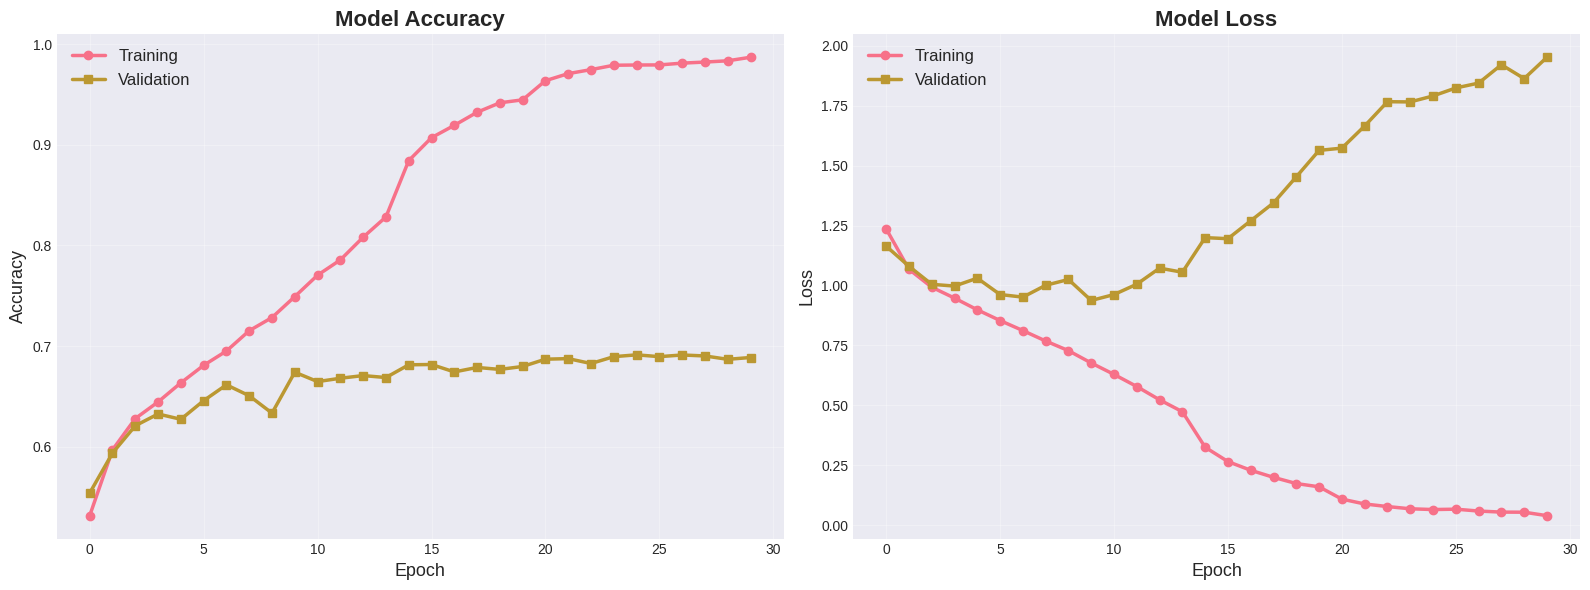


Final Training Metrics:
  Train Accuracy: 98.71%
  Validation Accuracy: 68.86%
  Best Validation Accuracy: 69.13%


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
axes[0].plot(history['train_acc'], label='Training', linewidth=2.5, marker='o', markersize=6)
axes[0].plot(history['val_acc'], label='Validation', linewidth=2.5, marker='s', markersize=6)
axes[0].set_title('Model Accuracy', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history['train_loss'], label='Training', linewidth=2.5, marker='o', markersize=6)
axes[1].plot(history['val_loss'], label='Validation', linewidth=2.5, marker='s', markersize=6)
axes[1].set_title('Model Loss', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Loss', fontsize=13)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal Training Metrics:")
print(f"  Train Accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"  Validation Accuracy: {history['val_acc'][-1]*100:.2f}%")
print(f"  Best Validation Accuracy: {best_val_acc*100:.2f}%")

## 14. Load Best Model & Evaluate

In [15]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  Best validation accuracy: {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Evaluating'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate final accuracy
final_accuracy = accuracy_score(all_labels, all_preds)
print(f"\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)
print(f"Test Accuracy: {final_accuracy*100:.2f}%")
print("="*50)

✓ Loaded best model from epoch 25
  Best validation accuracy: 69.13%


Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]


TEST SET EVALUATION
Test Accuracy: 69.13%


## 15. Classification Report

In [16]:
# Generate classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, 
                          target_names=EMOTION_CLASSES, 
                          digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.6212    0.6127    0.6169       958
     disgust     0.7113    0.6216    0.6635       111
        fear     0.5657    0.5342    0.5495      1024
       happy     0.8721    0.8760    0.8740      1774
     neutral     0.6408    0.6367    0.6387      1233
         sad     0.5626    0.5838    0.5730      1247
    surprise     0.7972    0.8327    0.8146       831

    accuracy                         0.6913      7178
   macro avg     0.6816    0.6711    0.6757      7178
weighted avg     0.6902    0.6913    0.6906      7178



## 16. Confusion Matrix

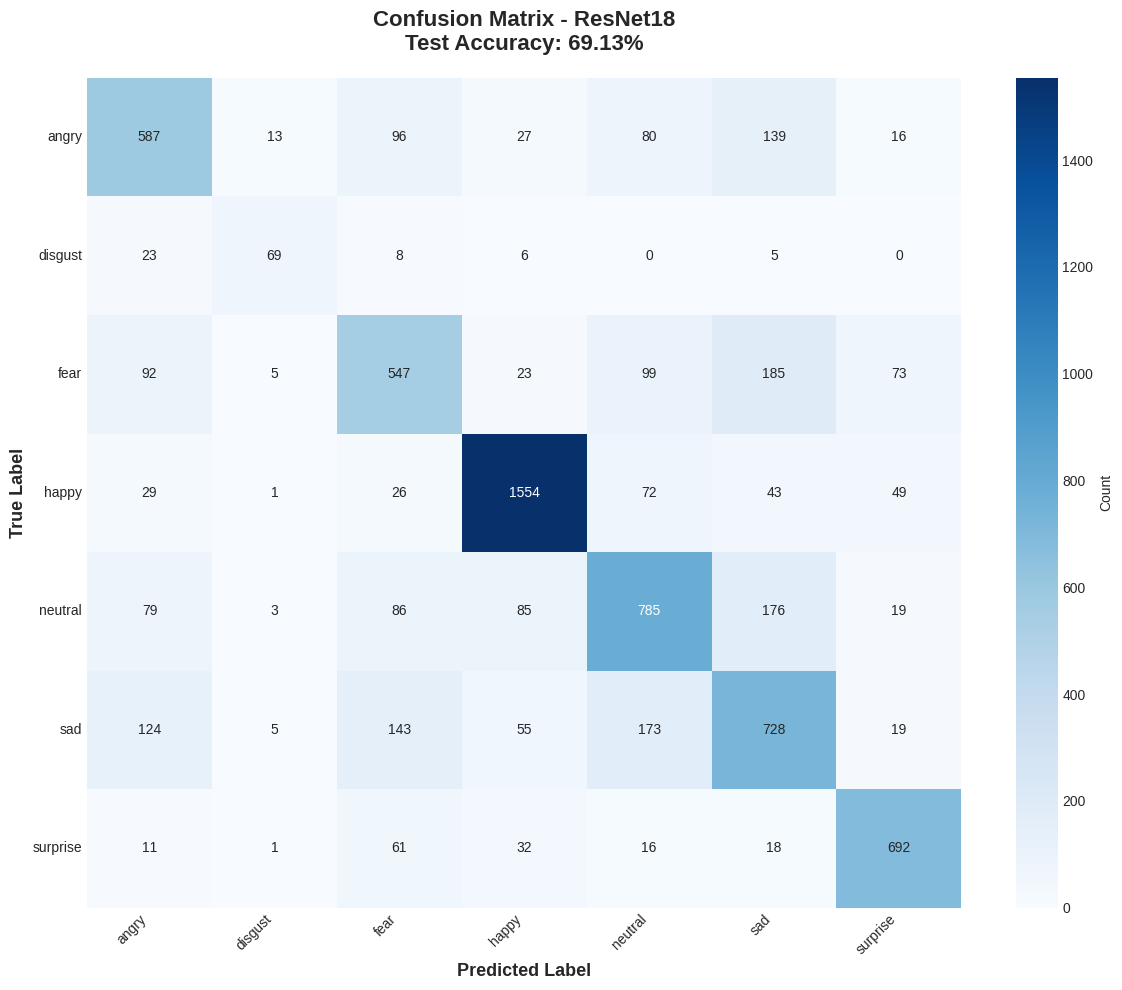


Per-Class Accuracy:
angry       :  61.27% (587/958)
disgust     :  62.16% (69/111)
fear        :  53.42% (547/1024)
happy       :  87.60% (1554/1774)
neutral     :  63.67% (785/1233)
sad         :  58.38% (728/1247)
surprise    :  83.27% (692/831)


In [17]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=EMOTION_CLASSES,
            yticklabels=EMOTION_CLASSES,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - ResNet18\nTest Accuracy: {final_accuracy*100:.2f}%',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-Class Accuracy:")
print("=" * 40)
for i, emotion in enumerate(EMOTION_CLASSES):
    class_acc = cm[i, i] / cm[i, :].sum() * 100 if cm[i, :].sum() > 0 else 0
    print(f"{emotion:12s}: {class_acc:6.2f}% ({cm[i, i]}/{cm[i, :].sum()})")
print("=" * 40)

## 17. Inference: Random Test Image

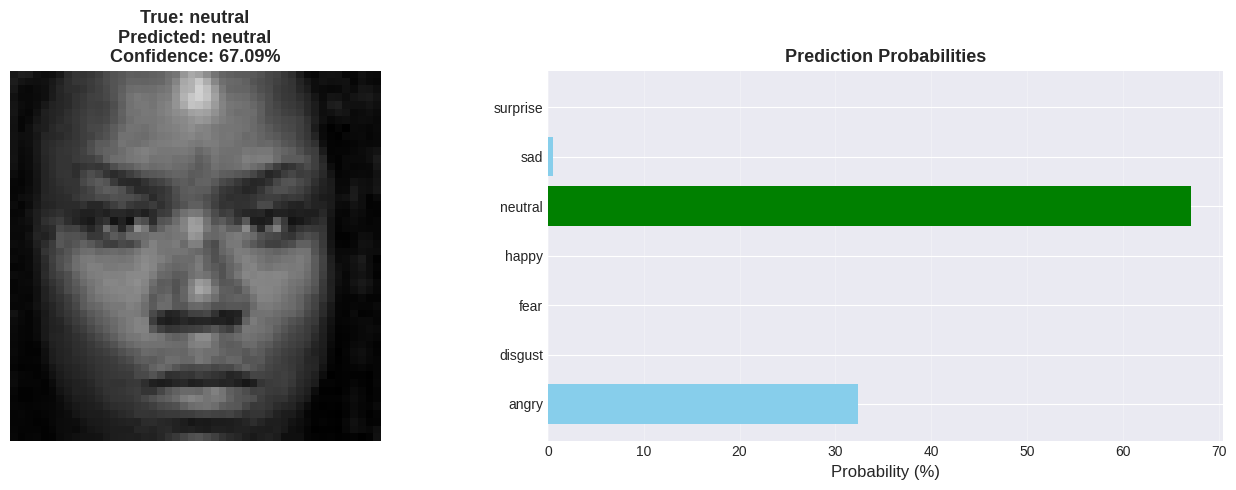


Prediction Details:
    angry       :  32.34%
    disgust     :   0.00%
    fear        :   0.00%
    happy       :   0.00%
  ★ neutral     :  67.09%
    sad         :   0.57%
    surprise    :   0.00%


In [18]:
def predict_emotion(model, img_path, transform, device, class_names):
    """
    Predict emotion from an image.
    """
    # Load and transform image
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)[0]
        predicted_idx = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_idx].item() * 100
    
    return img, class_names[predicted_idx], confidence, probabilities.cpu().numpy()

# Select random test image
random_emotion = random.choice(EMOTION_CLASSES)
emotion_path = os.path.join(TEST_DIR, random_emotion)
random_image = random.choice(os.listdir(emotion_path))
img_path = os.path.join(emotion_path, random_image)

# Predict
img, predicted_emotion, confidence, all_probs = predict_emotion(
    model, img_path, test_transform, device, EMOTION_CLASSES
)

# Visualize prediction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Display image
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f'True: {random_emotion}\nPredicted: {predicted_emotion}\nConfidence: {confidence:.2f}%',
                  fontsize=13, fontweight='bold')

# Display probabilities
colors = ['green' if EMOTION_CLASSES[i] == predicted_emotion else 'skyblue' 
          for i in range(len(EMOTION_CLASSES))]
axes[1].barh(EMOTION_CLASSES, all_probs * 100, color=colors)
axes[1].set_xlabel('Probability (%)', fontsize=12)
axes[1].set_title('Prediction Probabilities', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPrediction Details:")
for i, emotion in enumerate(EMOTION_CLASSES):
    prob = all_probs[i] * 100
    marker = "★" if emotion == predicted_emotion else " "
    print(f"  {marker} {emotion:12s}: {prob:6.2f}%")

## 18. Batch Predictions Visualization

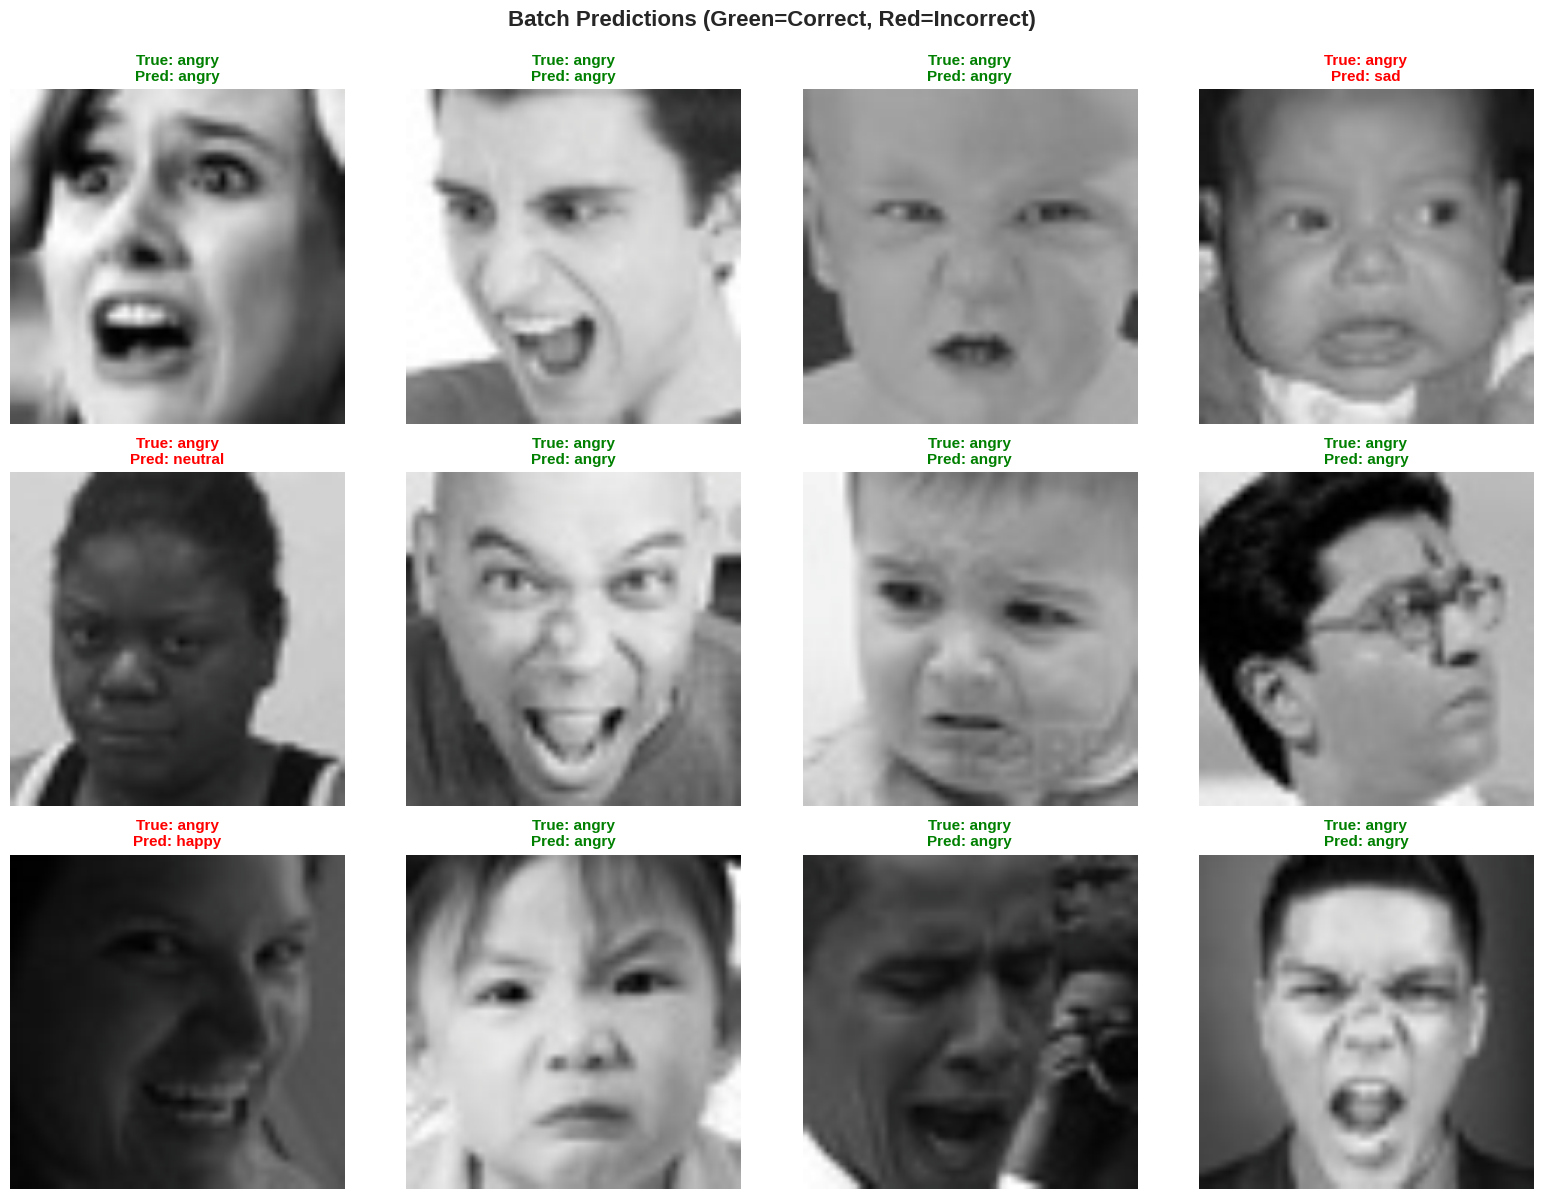

In [19]:
# Get a batch from test loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Predict on batch
images_gpu = images.to(device)
model.eval()
with torch.no_grad():
    outputs = model(images_gpu)
    _, predictions = torch.max(outputs, 1)

# Denormalize images for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_denorm = images * std + mean
images_denorm = torch.clamp(images_denorm, 0, 1)

# Display first 12 predictions
n_display = 12
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(n_display):
    img = images_denorm[i].permute(1, 2, 0).numpy()
    true_label = EMOTION_CLASSES[labels[i]]
    pred_label = EMOTION_CLASSES[predictions[i]]
    
    axes[i].imshow(img)
    axes[i].axis('off')
    
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}',
                     fontsize=11, color=color, fontweight='bold')

plt.suptitle('Batch Predictions (Green=Correct, Red=Incorrect)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 19. Final Summary

In [20]:
print("\n" + "="*70)
print(" "*20 + "FINAL SUMMARY")
print("="*70)
print(f"\n{'Metric':<35} {'Value':<20}")
print("-" * 55)
print(f"{'Model Architecture':<35} {'ResNet18':<20}")
print(f"{'Pretrained Weights':<35} {'ImageNet':<20}")
print(f"{'Input Size':<35} {f'{IMG_SIZE}x{IMG_SIZE}':<20}")
print(f"{'Number of Classes':<35} {NUM_CLASSES:<20}")
print(f"{'Training Samples':<35} {len(train_dataset):<20}")
print(f"{'Test Samples':<35} {len(test_dataset):<20}")
print(f"{'Batch Size':<35} {BATCH_SIZE:<20}")
print(f"{'Total Epochs':<35} {NUM_EPOCHS:<20}")
print(f"{'Learning Rate':<35} {LEARNING_RATE:<20}")
print("-" * 55)
print(f"{'Best Validation Accuracy':<35} {best_val_acc*100:.2f}%")
print(f"{'Final Test Accuracy':<35} {final_accuracy*100:.2f}%")
print("="*70)
print(f"\n✓ Best model saved to: {MODEL_SAVE_PATH}")
print("\n" + "="*70)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!")
print("="*70)


                    FINAL SUMMARY

Metric                              Value               
-------------------------------------------------------
Model Architecture                  ResNet18            
Pretrained Weights                  ImageNet            
Input Size                          224x224             
Number of Classes                   7                   
Training Samples                    28709               
Test Samples                        7178                
Batch Size                          64                  
Total Epochs                        30                  
Learning Rate                       0.001               
-------------------------------------------------------
Best Validation Accuracy            69.13%
Final Test Accuracy                 69.13%

✓ Best model saved to: /kaggle/working/resnet18_fer2013_best2.pth

NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY!


## 20. Save Results

In [21]:
import json
import pandas as pd

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv('/kaggle/working/training_history.csv', index=False)
print("✓ Training history saved")

# Save configuration and results
results = {
    'model': 'ResNet18',
    'dataset': 'FER-2013',
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(final_accuracy),
    'num_classes': NUM_CLASSES,
    'class_names': EMOTION_CLASSES,
    'total_train_samples': len(train_dataset),
    'total_test_samples': len(test_dataset)
}

with open('/kaggle/working/results_summary.json', 'w') as f:
    json.dump(results, f, indent=4)
print("✓ Results summary saved")

print("\n" + "="*50)
print("ALL OUTPUTS SAVED SUCCESSFULLY!")
print("="*50)

✓ Training history saved
✓ Results summary saved

ALL OUTPUTS SAVED SUCCESSFULLY!
